The DEM code is run in several different ways, with differences when it comes to the method for generating (or not generating) AIA inputs.
These are:

1. For most observations, AIA data is available on the NCCS. For observations where this is true, after time interval selection and NuSTAR-AIA offset selection, AIA region information is uploaded and data prep occurs there. Afterward, files containing AIA inputs are downloaded and used for DEMs. This is the first of the three methods included here.
2. For more recent observations, NCCS data is not available (it could be requested, given long lead times on uploads it was not). Instead, for these cases, files are requested from the JSOC and stored locally.
    - In addition to cases with no NCCS coverage, this is also the method used for a few observations where time interval selection was re-run later due to region definition errors. Specifically, for manual input regions, it was found that the region coordinates were being calculated incorrectly, leading to drift over time as the Sun moves.
    - For these cases, AIA data was downloaded only for intervals deemed quiescent (to reduce total data volume). 


 
3. In order to make time evolution plots for visualization purposes, an option in the DEM code allows an exit before DEM calculation, with NuSTAR inputs calculated only. This is the third option. 

In [1]:
path_to_dodem = '/Users/jmdunca2/do-dem/'
from sys import path as sys_path
sys_path.append(path_to_dodem+'/dodem/')

import all_nu_analysis as ana
import nustar_utilities as nuutil
import nustar_dem_prep as nu
import time_interval_selection as tis
import dodem as dodem

from astropy import units as u

import pickle
import importlib
import numpy as np

file='/Users/jmdunca2/do-dem/reference_files/all_targets_postghost_postshut.pickle'


#FOR UPDATING NEWER KEY DICTIONARY TO HAVE THE OLD AIA PATHS
def update_prepped_aia(key, currentfile='', updatefile='', 
                       demfolder='/Users/jmdunca2/do-dem/DEM_folders/'):
    
    with open(updatefile, 'rb') as f:
        data = pickle.load(f)
    
    prepped_aia_toupdate = data[key]['prepped_aia']
    prepped_aia_new = demfolder+('/').join(prepped_aia_toupdate.split('/')[-3:])
                                       
    with open(currentfile, 'rb') as f:
        data = pickle.load(f)
                                           
    data[key]['prepped_aia'] = prepped_aia_new
                                           
    with open(currentfile, 'wb') as f:
        #Pickle the 'data' dictionary using the highest protocol available.
        pickle.dump(data, f, pickle.HIGHEST_PROTOCOL) 


In [2]:
with open(file, 'rb') as f:
    data = pickle.load(f)

data.keys()

dict_keys(['01-nov-14_1', '01-nov-14_2', '11-dec-14', '19-feb-16', '22-apr-16_1', '22-apr-16_2', '26-jul-16_1', '27-jul-16_1', '26-jul-16_2', '10-oct-17', '29-may-18_1', '29-may-18_2', '07-sep-18', '09-sep-18', '10-sep-18', '12-apr-19', '13-apr-19', '29-jan-20', '06-jun-20', '07-jun-20', '08-jun-20', '09-jun-20', '08-jan-21', '14-jan-21', '20-jan-21', '29-apr-21', '03-may-21_1', '03-may-21_2', '30-jul-21_1', '30-jul-21_2', '17-nov-21_1', '19-nov-21', '20-nov-21', '22-nov-21_1', '22-nov-21_2', '03-jun-22_1', '03-jun-22_2', '06-sep-22', '09-dec-22', '17-nov-21_2', '21-nov-21', '30-jan-20', '20-jul-21', '24-feb-22', '25-feb-22', '27-feb-22', '18-mar-23_2', '11-dec-22_2'])

In [4]:
importlib.reload(ana)

#JSOC AIA GHOST CORR cases:
keys = [#'01-nov-14_1', #'01-nov-14_2', 
        #'11-dec-14', 
        #'29-may-18_2',
        #'30-jan-20',
        #'17-nov-21_2'
        #'19-nov-21', '20-nov-21', 
        #'21-nov-21', 
        #'22-nov-21_1',
        #'24-feb-22', 
        #'25-feb-22', 
        #'27-feb-22', 
        #'03-jun-22_2', 
        #'11-dec-22_2',
        ##'18-mar-23_1'
        ]


for key in keys:
    print('====================================================================================')
    print(key)
    print('====================================================================================')
    print('====================================================================================')
    print('====================================================================================')
    ana.post_tis_info_dump(key, file)
    with open(file, 'rb') as f:
        data = pickle.load(f)
    
    ARDict = data[key]
    #print(ARDict.keys())
    
    
    prqti = ARDict['per_region_quiet_time_intervals']
    #print([prqti])
    regdicts_all = ARDict['regdicts']
    #print(regdicts_all)
    
    
    for r in range(0, len(prqti)):
        ana.do_key_dem(key, file,
                       #ghost_corr = True, #Ghost ray correction - preparation for this needs to be done in ghost_correct.ipynb
                       #extraname='ghost_corr',
                       mc_rounds=1000,
                       asym_stdv_uncert=True,
                       use_prior_prep=False,
                       plot_xrt=False, plot_aia=False,
                  high_temp_analysis=True, rscl=True,
                  aia_region_dict=regdicts_all, #List of AIA regions - input for data prep
                  use_prepped_aia=False,
                  input_time_intervals=prqti, #Time intervals to do DEMs for
                  pick_region=True, #whether or not to do this only for one selected region (i.e. of several in the FOV)
                  regionind=r, #Index of desired region
                  do_no_xrt_version=False,
                  do_onlyaia_version=False,
                  do_aiaxrt_version=False)

24-feb-22
2021-01-08 12:21:25 2021-01-08 12:27:01
2021-01-08 12:39:07 2021-01-08 12:42:37
2021-01-08 11:56:31 2021-01-08 12:02:49
2021-01-14 11:37:36 2021-01-14 11:40:24
2021-01-20 12:28:02 2021-01-20 12:35:02
2021-01-20 12:32:44 2021-01-20 12:41:50
2021-01-20 12:24:02 2021-01-20 12:26:50
2021-01-20 14:07:23 2021-01-20 14:20:41
2021-01-20 14:16:17 2021-01-20 14:23:17
2021-01-20 12:26:30 2021-01-20 12:44:00
2021-01-20 14:07:15 2021-01-20 14:17:45
2021-01-20 14:15:00 2021-01-20 14:27:15
2021-01-14 10:13:22.500000 2021-01-14 11:03:15
2021-01-14 11:36:07.500000 2021-01-14 11:38:45
2021-01-14 10:13:22.500000 2021-01-14 11:03:15
2021-01-14 11:36:07.500000 2021-01-14 11:38:45
2021-01-14 14:35:52.500000 2021-01-14 14:40:15
2021-01-14 14:41:45 2021-01-14 14:47:00
2021-01-14 14:46:37.500000 2021-01-14 14:49:15
2021-01-14 14:47:52.500000 2021-01-14 14:54:00
2021-01-20 12:26:30 2021-01-20 12:44:00
2021-01-20 14:07:15 2021-01-20 14:17:45
2021-01-20 14:15:00 2021-01-20 14:27:15
2021-01-14 10:13:22.5

20-jan-21
NAME BEFORE:  20-jan-21
NAME AFTER:  20-jan-21_no_xrt
XRT is:  False
Found no AIA
Found no AIA
Found no AIA
Found no AIA
Found no AIA
Found no AIA
Found no AIA
Found no AIA
Found no AIA
Found no AIA
Found no AIA
Found no AIA
Start Time:  2021-01-20 12:17:30
Stop Time:  2021-01-20 12:20:40

Using inputs from prior DEM run, saved in this file: 
/Users/jmdunca2/do-dem/DEM_folders/initial_dem_20jan21/12-17-30_12-20-40/12-17-30_12-20-40_5.6_7.2_20-jan-21_no_xrt_MC_DEM_result.pickle

A94 :     2.79   1.46  52 %
A131 :     21.70   3.99  18 %
A171 :     497.36   52.48  11 %
A193 :     933.98   95.79  10 %
A211 :     405.44   42.05  10 %
A335 :     18.18   2.68  15 %
2.5-3.5keV A+B :     3887.68   778.26  20 %
3.5-6.0keV A+B :     565.85   113.89  20 %
6.0-10.0keV A+B :     2.64   1.02  39 %
DN INs:  [2.7896336966233033, 21.702193612549973, 497.3552588530934, 933.9760843093981, 405.44188387579044, 18.17688513994162, 3887.6787451871833, 565.8494787694625, 2.643125750054898]

Doing 1000

KeyboardInterrupt: 

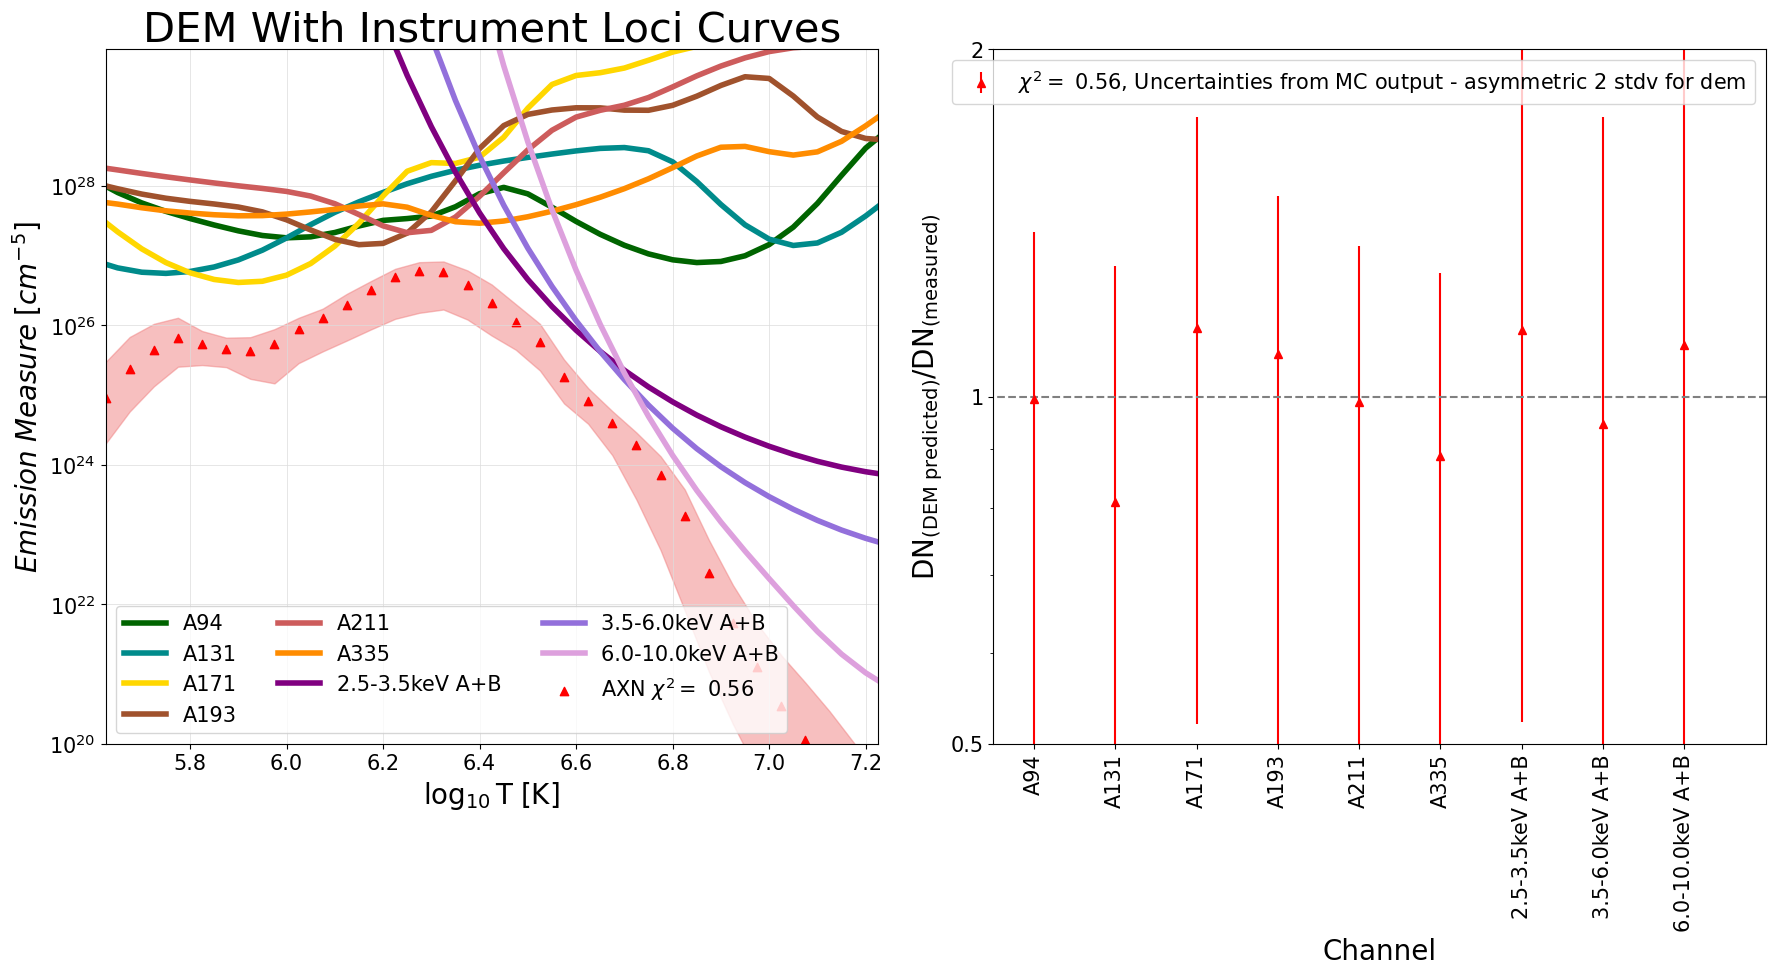

In [4]:
#AIA from saved NCCS inputs

#key='20-jul-21'

#NCCS AIA cases (non-ghost)
keys=[#'22-apr-16_2', 
    '29-may-18_1', 
    #'09-sep-18', '10-sep-18', 
    '12-apr-19', '13-apr-19', 
    '29-jan-20', 
    #'06-jun-20', '07-jun-20', '08-jun-20', '09-jun-20', 
    #'08-jan-21', '20-jan-21', 
     '29-apr-21']#, 
    #'03-may-21_1']

keys=['20-jan-21']

importlib.reload(ana)

for key in keys:
    print(key)
    #Need to point to the NCCS inputs (if this has not yet been done). Using an old file to update the current megadict.
    update_prepped_aia(key, currentfile=file,
                      updatefile='/Users/jmdunca2/do-dem/reference_files/all_targets.pickle')
    
    # with open(file, 'rb') as f:
    #     data = pickle.load(f)
    
    # ARDict = data[key]
    # #print(ARDict.keys())
    
    
    # prqti2 = ARDict['per_region_quiet_time_intervals']


    
    ana.do_key_dem(key, file, 
                   quiet_only=False,
                   mc_rounds=1000,
                   asym_stdv_uncert=True,
                   plot_xrt=False, plot_aia=False,
                   use_prior_prep=True,
                   use_prepped_aia=True,
                   high_temp_analysis=False, rscl=True,
                   do_no_xrt_version=True,
                   do_onlyaia_version=False,
                   do_aiaxrt_version=False)
    
    ana.do_key_dem(key, file, 
                   quiet_only=False,
                   mc_rounds=1000,
                   asym_stdv_uncert=True,
                   plot_xrt=False, plot_aia=False,
                   use_prior_prep=True,
                   use_prepped_aia=True,
                   high_temp_analysis=False, rscl=True,
                   do_no_xrt_version=False,
                   do_onlyaia_version=True,
                   do_aiaxrt_version=False)

    ana.do_key_dem(key, file, 
                   quiet_only=False,
                   mc_rounds=1000,
                   asym_stdv_uncert=True,
                   plot_xrt=False, plot_aia=False,
                   use_prior_prep=True,
                   use_prepped_aia=True,
                   high_temp_analysis=False, rscl=True,
                   do_no_xrt_version=False,
                   do_onlyaia_version=False,
                   do_aiaxrt_version=True)

In [3]:
importlib.reload(ana)

#NCCS AIA cases (GHOST CORR)
keys=[#'19-feb-16', 
    '30-jul-21_1', '30-jul-21_2', '03-may-21_2']
    #, '20-jul-21']


for key in keys:
    #Need to point to the NCCS inputs (if this has not yet been done). Using an old file to update the current megadict.
    update_prepped_aia(key, currentfile=file,
                      updatefile='/Users/jmdunca2/do-dem/reference_files/all_targets.pickle')
    
    #ana.post_tis_info_dump(key, file)
    
    ana.do_key_dem(key, file, 
                   quiet_only=True,
                   ghost_corr = True, #Ghost ray correction - preparation for this needs to be done in ghost_correct.ipynb
                   extraname='ghost_corr',
                   mc_rounds=1000,
                   asym_stdv_uncert=True,
                   use_prior_prep=True,
                   plot_xrt=False, plot_aia=False,
                   use_prepped_aia=True,
                   high_temp_analysis=False, rscl=True,
                   do_no_xrt_version=True,
                   do_onlyaia_version=False,
                   do_aiaxrt_version=False)
    

    ana.do_key_dem(key, file, 
                   quiet_only=True,
                   ghost_corr = True, #Ghost ray correction - preparation for this needs to be done in ghost_correct.ipynb
                   extraname='ghost_corr',
                   mc_rounds=1000,
                   asym_stdv_uncert=True,
                   use_prior_prep=True,
                   plot_xrt=False, plot_aia=False,
                   use_prepped_aia=True,
                   high_temp_analysis=False, rscl=True,
                   do_no_xrt_version=False,
                   do_onlyaia_version=True,
                   do_aiaxrt_version=False)


    ana.do_key_dem(key, file, 
                   quiet_only=True,
                   ghost_corr = True, #Ghost ray correction - preparation for this needs to be done in ghost_correct.ipynb
                   extraname='ghost_corr',
                   mc_rounds=1000,
                   asym_stdv_uncert=True,
                   use_prior_prep=True,
                   plot_xrt=False, plot_aia=False,
                   use_prepped_aia=True,
                   high_temp_analysis=False, rscl=True,
                   do_no_xrt_version=False,
                   do_onlyaia_version=False,
                   do_aiaxrt_version=True)

NAME BEFORE:  30-jul-21_1ghost_corr
NAME AFTER:  30-jul-21_1ghost_corr_no_xrt
XRT is:  False
xrt is:  False
Time Intervals for this region/orbit:  [<Time object: scale='utc' format='datetime' value=[datetime.datetime(2021, 7, 30, 18, 5, 5)
 datetime.datetime(2021, 7, 30, 19, 5, 35)]>]
flaretime, exiting.
Time Intervals for this region/orbit:  [<Time object: scale='utc' format='datetime' value=[datetime.datetime(2021, 7, 30, 18, 5, 5)
 datetime.datetime(2021, 7, 30, 18, 31, 55)]>, <Time object: scale='utc' format='datetime' value=[datetime.datetime(2021, 7, 30, 18, 31, 55)
 datetime.datetime(2021, 7, 30, 19, 5, 35)]>]
flaretime, exiting.
flaretime, exiting.
XRT is:  False
xrt is:  False
Time Intervals for this region/orbit:  [[<Time object: scale='utc' format='datetime' value=2021-07-30 21:18:20>, <Time object: scale='utc' format='datetime' value=2021-07-30 22:18:50>]]
quiet time, doing DEM.
xrt is:  False
Start Time:  2021-07-30 21:18:20
Stop Time:  2021-07-30 22:18:50

Using input reg

In [5]:
importlib.reload(ana)

key='01-nov-14_1'

#JSOC AIA cases:
keys = [#'01-nov-14_1', '11-dec-14', '26-jul-16_1', '26-jul-16_2', '27-jul-16_1', '10-oct-17', '29-may-18_2', 
        #'07-sep-18', '30-jan-20', 
        '14-jan-21', '17-nov-21_1']#, 
        #'19-nov-21', '20-nov-21', '21-nov-21', 
        #'22-nov-21_1', '24-feb-22', '25-feb-22', '27-feb-22','03-jun-22_2', '06-sep-22', '09-dec-22', '11-dec-22_2', '18-mar-23_1']


for key in keys:
    print('====================================================================================')
    print(key)
    print('====================================================================================')
    print('====================================================================================')
    print('====================================================================================')
    ana.post_tis_info_dump(key, file)
    with open(file, 'rb') as f:
        data = pickle.load(f)
    
    ARDict = data[key]
    #print(ARDict.keys())
    
    
    prqti = ARDict['per_region_quiet_time_intervals']
    print([prqti])
    regdicts_all = ARDict['regdicts']
    
    
    for r in range(0, len(prqti)):
        ana.do_key_dem(key, file,
                       mc_rounds=1000,
                       asym_stdv_uncert=True,
                       use_prior_prep=True,
                       plot_xrt=False, plot_aia=False,
                  high_temp_analysis=False, rscl=True,
                  aia_region_dict=regdicts_all, #List of AIA regions - input for data prep
                  use_prepped_aia=False,
                  input_time_intervals=prqti, #Time intervals to do DEMs for
                  pick_region=True, #whether or not to do this only for one selected region (i.e. of several in the FOV)
                  regionind=r, #Index of desired region
                  do_no_xrt_version=True,
                  do_onlyaia_version=False,
                  do_aiaxrt_version=False)



        ana.do_key_dem(key, file,
                       mc_rounds=1000,
                       asym_stdv_uncert=True,
                       use_prior_prep=True,
                       plot_xrt=False, plot_aia=False,
                  high_temp_analysis=False, rscl=True,
                  aia_region_dict=regdicts_all, #List of AIA regions - input for data prep
                  use_prepped_aia=False,
                  input_time_intervals=prqti, #Time intervals to do DEMs for
                  pick_region=True, #whether or not to do this only for one selected region (i.e. of several in the FOV)
                  regionind=r, #Index of desired region
                  do_no_xrt_version=False,
                  do_onlyaia_version=True,
                  do_aiaxrt_version=False)


        ana.do_key_dem(key, file,
                       mc_rounds=1000,
                       asym_stdv_uncert=True,
                       use_prior_prep=True,
                       plot_xrt=False, plot_aia=False,
                  high_temp_analysis=False, rscl=True,
                  aia_region_dict=regdicts_all, #List of AIA regions - input for data prep
                  use_prepped_aia=False,
                  input_time_intervals=prqti, #Time intervals to do DEMs for
                  pick_region=True, #whether or not to do this only for one selected region (i.e. of several in the FOV)
                  regionind=r, #Index of desired region
                  do_no_xrt_version=False,
                  do_onlyaia_version=False,
                  do_aiaxrt_version=True)

14-jan-21
2021-01-08 12:21:25 2021-01-08 12:27:01
2021-01-08 12:39:07 2021-01-08 12:42:37
2021-01-08 11:56:31 2021-01-08 12:02:49
2021-01-14 11:37:36 2021-01-14 11:40:24
2021-01-20 12:28:02 2021-01-20 12:35:02
2021-01-20 12:32:44 2021-01-20 12:41:50
2021-01-20 12:24:02 2021-01-20 12:26:50
2021-01-20 14:07:23 2021-01-20 14:20:41
2021-01-20 14:16:17 2021-01-20 14:23:17
2021-01-20 12:26:30 2021-01-20 12:44:00
2021-01-20 14:07:15 2021-01-20 14:17:45
2021-01-20 14:15:00 2021-01-20 14:27:15
2021-01-14 10:13:22.500000 2021-01-14 11:03:15
2021-01-14 11:36:07.500000 2021-01-14 11:38:45
2021-01-14 10:13:22.500000 2021-01-14 11:03:15
2021-01-14 11:36:07.500000 2021-01-14 11:38:45
2021-01-14 14:35:52.500000 2021-01-14 14:40:15
2021-01-14 14:41:45 2021-01-14 14:47:00
2021-01-14 14:46:37.500000 2021-01-14 14:49:15
2021-01-14 14:47:52.500000 2021-01-14 14:54:00
2021-01-20 12:26:30 2021-01-20 12:44:00
2021-01-20 14:07:15 2021-01-20 14:17:45
2021-01-20 14:15:00 2021-01-20 14:27:15
2021-01-14 10:13:22.5

In [13]:
#JSOC AIA GHOST CORR cases:
keys = ['01-nov-14_1', '11-dec-14', 
        '29-may-18_2',
        '30-jan-20',
        '17-nov-21_2','19-nov-21', '20-nov-21', '21-nov-21', '22-nov-21_1',
        '24-feb-22', '25-feb-22', '27-feb-22', '03-jun-22_2', '11-dec-22_2',
        '18-mar-23_1']

keys=['19-feb-16',  '03-may-21_2', '30-jul-21_1', '30-jul-21_2', '20-jul-21']


with open(file, 'rb') as f:
        data = pickle.load(f)

for key in keys:
    ARDict = data[key]
    #print(key)
    if 'Ghost_Ray_Rate_A' in ARDict.keys():
        print(key)

19-feb-16
03-may-21_2
30-jul-21_1
20-jul-21


In [ ]:
xrtkeys = ['29-may-18_1', '12-apr-19', '13-apr-19', '29-jan-20', '29-apr-21', 
           '3-may-21_2', '30-jul-21_1', '30-jul-21_2',
           '14-jan-21', '17-nov-21_1']

In [ ]:
importlib.reload(ana)

key='11-dec-22_2'
#key='12-apr-19'

ana.post_tis_info_dump(key, file)
with open(file, 'rb') as f:
    data = pickle.load(f)

ARDict = data[key]
#print(ARDict.keys())


prqti = ARDict['per_region_quiet_time_intervals']
print([prqti])
regdicts_all = ARDict['regdicts']


for r in range(0, len(prqti)):
    ana.do_key_dem(key, file, 
                   ghost_corr = True, #Ghost ray correction - preparation for this needs to be done in ghost_correct.ipynb
                   extraname='ghost_corr',
                   use_prior_prep=False,
                   plot_xrt=False, plot_aia=False,
              high_temp_analysis=True, rscl=True,
              aia_region_dict=regdicts_all, #List of AIA regions - input for data prep
              use_prepped_aia=False,
              input_time_intervals=prqti, #Time intervals to do DEMs for
              pick_region=True, #whether or not to do this only for one selected region (i.e. of several in the FOV)
              regionind=r, #Index of desired region
              do_no_xrt_version=False,
              do_onlyaia_version=False,
              do_aiaxrt_version=False)

In [ ]:
importlib.reload(ana)

key='11-dec-14'
#key='12-apr-19'


with open(file, 'rb') as f:
    data = pickle.load(f)

ARDict = data[key]
#print(ARDict.keys())

prqti = ARDict['per_region_quiet_time_intervals']
#print([prqti[0]])
regdicts_all = ARDict['regdicts']

# for r in range(0, len(prqti)):
#     ana.do_key_dem(key, #index of obs. key dict.
#                file, #file containing obs. key dict (pickle)
#                plot_xrt=False, plot_aia=False,
#               high_temp_analysis=True, rscl=True,
#               aia_region_dict=regdicts_all, #List of AIA regions - input for data prep
#               use_prepped_aia=False, #We will prep it here (or use prepped inputs)
#               input_time_intervals=[prqti[r]], #Time intervals to do DEMs for
#                pick_region=True, #whether or not to do this only for one selected region (i.e. of several in the FOV)
#                regionind=r #Index of desired region
#               ) 



for r in range(0, len(prqti)):
    # ana.do_key_dem(key, file, 
    #                use_prior_prep=True,
    #                plot_xrt=False, plot_aia=False,
    #           high_temp_analysis=False, rscl=True,
    #           aia_region_dict=regdicts_all, #List of AIA regions - input for data prep
    #           use_prepped_aia=False,
    #           input_time_intervals=prqti, #Time intervals to do DEMs for
    #           pick_region=True, #whether or not to do this only for one selected region (i.e. of several in the FOV)
    #           regionind=r, #Index of desired region
    #           do_no_xrt_version=False,
    #           do_onlyaia_version=False,
    #           do_aiaxrt_version=False)


    ana.do_key_dem(key, file, 
                   plot_xrt=False, plot_aia=False,
                  high_temp_analysis=False, rscl=True,
                  aia_region_dict=regdicts_all, #List of AIA regions - input for data prep
                  use_prepped_aia=False,
                  input_time_intervals=[prqti[r]], #Time intervals to do DEMs for
                  pick_region=True, #whether or not to do this only for one selected region (i.e. of several in the FOV)
                  regionind=r, #Index of desired region
                  do_no_xrt_version=True,
                  do_onlyaia_version=False,
                  do_aiaxrt_version=False)


    ana.do_key_dem(key, file, 
                  plot_xrt=False, plot_aia=False,
                  high_temp_analysis=False, rscl=True,
                  aia_region_dict=regdicts_all, #List of AIA regions - input for data prep
                  use_prepped_aia=False,
                  input_time_intervals=[prqti[r]], #Time intervals to do DEMs for
                  pick_region=True, #whether or not to do this only for one selected region (i.e. of several in the FOV)
                  regionind=r, #Index of desired region
                  do_no_xrt_version=False,
                  do_onlyaia_version=True,
                  do_aiaxrt_version=False)

    
    ana.do_key_dem(key, file, 
                  plot_xrt=True, plot_aia=False,
                  high_temp_analysis=False, rscl=True,
                  aia_region_dict=regdicts_all, #List of AIA regions - input for data prep
                  use_prepped_aia=False,
                  input_time_intervals=[prqti[r]], #Time intervals to do DEMs for
                  pick_region=True, #whether or not to do this only for one selected region (i.e. of several in the FOV)
                  regionind=r, #Index of desired region
                  do_no_xrt_version=False,
                  do_onlyaia_version=False,
                  do_aiaxrt_version=True)




In [ ]:
importlib.reload(ana)

key='07-sep-18'
#key='12-apr-19'


with open(file, 'rb') as f:
    data = pickle.load(f)

ARDict = data[key]
#print(ARDict.keys())

prqti = ARDict['per_region_quiet_time_intervals']
#print([prqti[0]])
regdicts_all = ARDict['regdicts']

for r in range(0, len(prqti)):
    ana.do_key_dem(key, #index of obs. key dict.
               file, #file containing obs. key dict (pickle)
               plot_xrt=False, plot_aia=False,
              high_temp_analysis=False, rscl=True,
              #aia_region_dict=regdicts_all, #List of AIA regions - input for data prep
              use_prepped_aia=False, #We will prep it here (or use prepped inputs)
              input_time_intervals=[prqti[r]], #Time intervals to do DEMs for
               pick_region=True, #whether or not to do this only for one selected region (i.e. of several in the FOV)
               regionind=r, #Index of desired region
              save_inputs_file=True) 


In [ ]:
#shorter example for troubleshooting astropy attribute error
# key='09-dec-22'

# regfile = '/Volumes/Orange/do-dem-stuffs//initial_dem_9dec22/gauss_cen_20801011001_A_0.reg'

# with open(file, 'rb') as f:
#     data = pickle.load(f)

# ARDict = data[key]

# id_dirs = ARDict['datapaths']


# directories = ana.get_region_directories(key, targets_file=file)
# print('1',directories)
# import time_interval_selection as tis
# all_all_time_intervals, fixit = tis.region_time_intervals(directories, id_dirs, shush=True) 

# time0, time1 = all_all_time_intervals[0][0][0]

# import region_fitting as rf

# rf.read_regfile(regfile, time0, time1, 'hourangle')

[1044.91797183  -74.99207718] arcsec


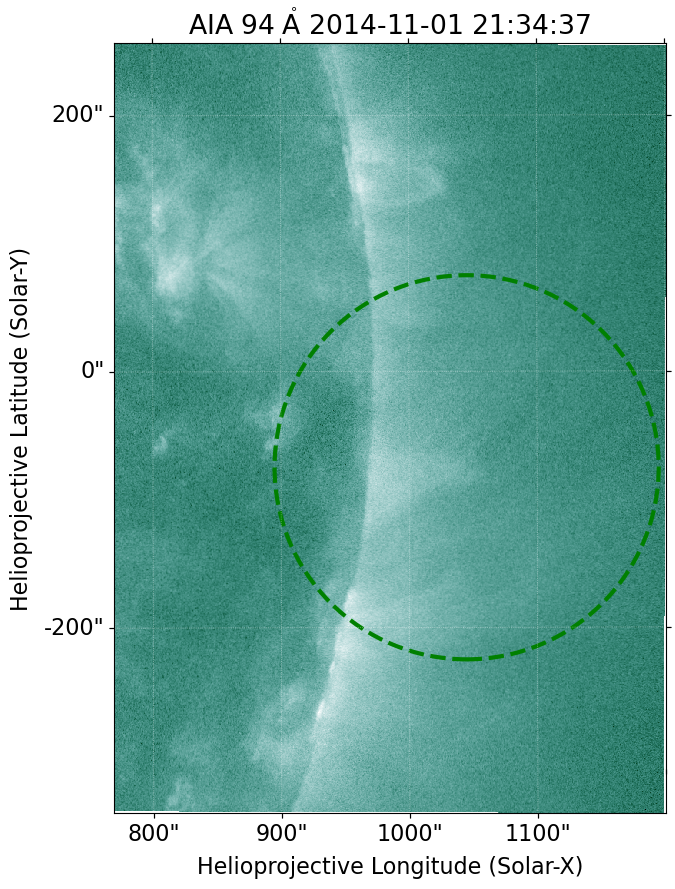

In [4]:
#Getting to the bottom of why a region was breaking the aia data prep - 
#ended up being just slightly over the edge of the AIA data (which we don't allow)

import sunpy.map
from astropy.coordinates import SkyCoord
from astropy import coordinates as coord
from regions import CircleSkyRegion
import region_fitting as rf
from matplotlib import pyplot as plt

mm = sunpy.map.Map('/Users/jmdunca2/do-dem/DEM_folders//initial_dem_1nov14_1/region_1/21-34-45_21-47-50/map_t14-11-01_21-34-37_prep_094.fits')
#mm = sunpy.map.Map('/Users/jmdunca2/do-dem/DEM_folders/aia_cutout_files/initial_dem_1nov14_1/region_1/aia.lev1_euv_12s.2014-11-01T213437Z.94.image.fits')
mm = sunpy.map.Map('/Users/jmdunca2/do-dem/DEM_folders//initial_dem_1nov14_1/region_1/21-34-45_21-47-50/map_t14-11-01_21-34-37_prep_094.fits')

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection=mm)
mm.plot()

time0 = prqti[1][0][0][0]
time1 = prqti[1][0][0][1]

regfile = '/Users/jmdunca2/do-dem/DEM_folders//initial_dem_1nov14_1/gauss_cen_20012001001_A_user_input_1.reg'

offset, rad = rf.read_regfile(regfile, time0, time1, 'hourangle')
print(offset)
center = SkyCoord( *(offset[0].value, offset[1].value)*u.arcsec, frame=mm.coordinate_frame)
region = CircleSkyRegion(
        center = center,
        radius = rad
    )

og_region = region.to_pixel(mm.wcs)
og_region.plot(axes=ax, color='green', ls='--', lw=3)

